# Causal Inference with DML — NLSAA Elderly Dataset

### Dataset
Ying Yan, Qi Huang. Dataset of depression and anxiety among the elderly derived from The Nottingham Longitudinal Study of Activity and Ageing (NLSAA) project[DS/OL]. V2. Science Data Bank, 2022[2026-08-22]. https://cstr.cn/31253.11.sciencedb.06263. CSTR:31253.11.sciencedb.06263.

### Research question
Estimate the causal relationship/effect of **loneliness (`lonely`)** on **`psych_85`**, adjusting for observed confounders.

### Important treatment coding
`lonely` is an ordinal score from **0–4**. There is only **one observation with `lonely = 0`**, so this notebook removes that observation before estimation.

The treatment is therefore **multi-valued/discrete: 1, 2, 3, 4**.

Scale Directionality:
0 = Always (Highest loneliness exposure)
1 = Most of the time
2 = Often
3 = Sometimes
4 = Never / Rarely (Lowest loneliness exposure)

The DML models use `discrete_treatment=True`, so the treatment is treated as a categorical treatment rather than incorrectly assuming that the difference between 1→2 is necessarily the same as 3→4.

The main comparison is relative to the lowest observed loneliness level, `lonely = 1`.

> Causal interpretation requires assumptions including consistency/SUTVA, positivity/overlap, and no important unobserved confounding.

In [1]:
# Install once if necessary
# !pip install econml xgboost scikit-learn pandas numpy matplotlib seaborn statsmodels

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from econml.dml import LinearDML, CausalForestDML

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded.")

Libraries loaded.


In [3]:
# Load dataset
file_path = "Data of Depression and Anxiety in the Elderly-NLSAAderived.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1215, 55)


,sex,age,cape,mstat,class_1,x_cohb,hltidx,hbound,blind,hearg,...,finsat,mxgrip,mxspan,mxflex,x_mobi,psych_85,wgtcat,agegroup,sleep,slpsev
0,1,68,2.0,3.0,3.0,0.0,7.0,0.0,0.0,0.0,...,1.0,24.5,87.6,120.0,1.0,0.0,1.0,1,1.0,1.0
1,1,69,2.0,1.0,2.0,1.0,4.0,0.0,0.0,0.0,...,2.0,48.3,84.2,144.0,1.0,0.0,3.0,1,0.0,0.0
2,1,74,2.0,1.0,2.0,1.0,1.0,0.0,0.0,1.0,...,2.0,31.0,79.7,132.0,1.0,0.0,1.0,2,0.0,0.0
3,1,70,2.0,3.0,2.0,1.0,NaN,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,2,NaN,NaN
4,1,68,2.0,1.0,2.0,1.0,2.0,0.0,0.0,0.0,...,2.0,45.7,81.2,130.0,1.0,0.0,3.0,1,0.0,0.0


In [4]:
# ---------------------------------------------------------
# Variables
# ---------------------------------------------------------

TREATMENT = "lonely"
OUTCOME = "psych_85"

confounders = [
    "sex",
    "age",
    "mstat",
    "class_1",
    "ses",
    "hltidx",
    "hbound",
    "blind",
    "hearg",
    "hi_bp",
    "x_illdis",
    "arthp",
    "pndex",
    "qfall",
    "smoke_do",
    "presc",
    "n_drug",
    "x_job",
    "minwlk",
    "minshp",
    "x_mobi",
    "wgtcat"
]

required_columns = [TREATMENT, OUTCOME] + confounders

missing_columns = [
    c for c in required_columns
    if c not in df.columns
]

if missing_columns:
    raise ValueError(
        f"These columns are missing from the dataset: {missing_columns}"
    )

print("Treatment:", TREATMENT)
print("Outcome:", OUTCOME)
print("Number of confounders:", len(confounders))

Treatment: lonely
Outcome: psych_85
Number of confounders: 22


In [5]:
# Inspect loneliness distribution BEFORE deleting lonely = 0

print("Loneliness distribution:")
display(
    df[TREATMENT]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nNumber of observations with lonely = 0:",
      (df[TREATMENT] == 0).sum())

Loneliness distribution:


lonely
0.0      1
1.0    237
2.0    175
3.0    155
4.0    591
NaN     56
Name: count, dtype: int64


Number of observations with lonely = 0: 1


## 1. Remove the single observation with `lonely = 0`

Because `lonely = 0` occurs only once, it is removed.

We also remove observations with missing treatment or outcome.

After this step, the treatment levels should be:

**1, 2, 3, 4**.

In [6]:
# Keep only observations with loneliness 1-4
data = df[
    (df[TREATMENT].notna()) &
    (df[OUTCOME].notna()) &
    (df[TREATMENT] != 0)
].copy()

print("Original N:", len(df))
print("N after removing lonely = 0 and missing T/Y:", len(data))
print("Removed:", len(df) - len(data))

print("\nLoneliness distribution AFTER filtering:")
display(
    data[TREATMENT]
    .value_counts()
    .sort_index()
)

Original N: 1215
N after removing lonely = 0 and missing T/Y: 1151
Removed: 64

Loneliness distribution AFTER filtering:


lonely
1.0    236
2.0    173
3.0    153
4.0    589
Name: count, dtype: int64

In [7]:
# Check treatment coding
loneliness_levels = sorted(data[TREATMENT].unique())

print("Loneliness levels:", loneliness_levels)

if not set(loneliness_levels).issubset({1, 2, 3, 4}):
    raise ValueError(
        f"Unexpected loneliness levels: {loneliness_levels}"
    )

# Outcome must be binary for this notebook
outcome_levels = sorted(data[OUTCOME].unique())

print("Outcome levels:", outcome_levels)

if not set(outcome_levels).issubset({0, 1}):
    raise ValueError(
        f"{OUTCOME} must be coded 0/1. Found: {outcome_levels}"
    )

Loneliness levels: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
Outcome levels: [np.float64(0.0), np.float64(1.0)]


## 2. Create `X`, `T`, and `Y`

We keep:

- `lonely = 1`
- `lonely = 2`
- `lonely = 3`
- `lonely = 4`

as a **multi-valued discrete treatment**.

`lonely = 1` is the lowest observed treatment level and is used as the reference level.

In [8]:
T = data[TREATMENT].astype(int).to_numpy().ravel()
Y = data[OUTCOME].astype(int).to_numpy().ravel()

print("T shape:", T.shape)
print("Y shape:", Y.shape)
print("Unique T:", np.unique(T))
print("Unique Y:", np.unique(Y))

T shape: (1151,)
Y shape: (1151,)
Unique T: [1 2 3 4]
Unique Y: [0 1]


## 3. Missing confounders

Continuous variables → **median**

Categorical/binary variables → **mode**

Treatment and outcome are never imputed.

In [9]:
numeric_vars = [
    "age",
    "ses",
    "hltidx",
    "hbound",
    "pndex",
    "n_drug",
    "minwlk",
    "minshp"
]

categorical_vars = [
    "sex",
    "mstat",
    "class_1",
    "blind",
    "hearg",
    "hi_bp",
    "x_illdis",
    "arthp",
    "qfall",
    "smoke_do",
    "presc",
    "x_job",
    "x_mobi",
    "wgtcat"
]

classified = numeric_vars + categorical_vars

if set(classified) != set(confounders):
    raise ValueError("The confounder lists do not match `confounders`.")

if len(classified) != len(set(classified)):
    raise ValueError("A confounder appears in more than one list.")

X_raw = data[confounders].copy()

print("Missing values before imputation:")
display(
    X_raw.isna().sum()
    .sort_values(ascending=False)
    .to_frame("Missing")
)

Missing values before imputation:


,Missing
minwlk,110
x_illdis,90
wgtcat,30
minshp,21
hltidx,9
ses,7
class_1,5
arthp,3
qfall,1
hi_bp,1


In [10]:
# Impute X
X_imputed = X_raw.copy()

# Median for continuous variables
for col in numeric_vars:
    X_imputed[col] = X_imputed[col].fillna(
        X_imputed[col].median()
    )

# Mode for categorical/binary variables
for col in categorical_vars:
    mode = X_imputed[col].mode(dropna=True)

    if len(mode) == 0:
        raise ValueError(f"No valid mode available for {col}")

    X_imputed[col] = X_imputed[col].fillna(mode.iloc[0])

# Convert to numerical matrix
X = X_imputed[confounders].to_numpy(dtype=float)

print("X shape:", X.shape)
print("NaN in X:", np.isnan(X).sum())
print("Inf in X:", np.isinf(X).sum())
print("NaN in T:", np.isnan(T).sum())
print("NaN in Y:", np.isnan(Y).sum())

X shape: (1151, 22)
NaN in X: 0
Inf in X: 0
NaN in T: 0
NaN in Y: 0


In [11]:
# Verify that all dimensions match

print("Number of observations:")
print("X:", X.shape[0])
print("T:", T.shape[0])
print("Y:", Y.shape[0])

assert X.shape[0] == len(T) == len(Y)

print("\nDimension check passed.")

Number of observations:
X: 1151
T: 1151
Y: 1151

Dimension check passed.


## 4. Descriptive analysis

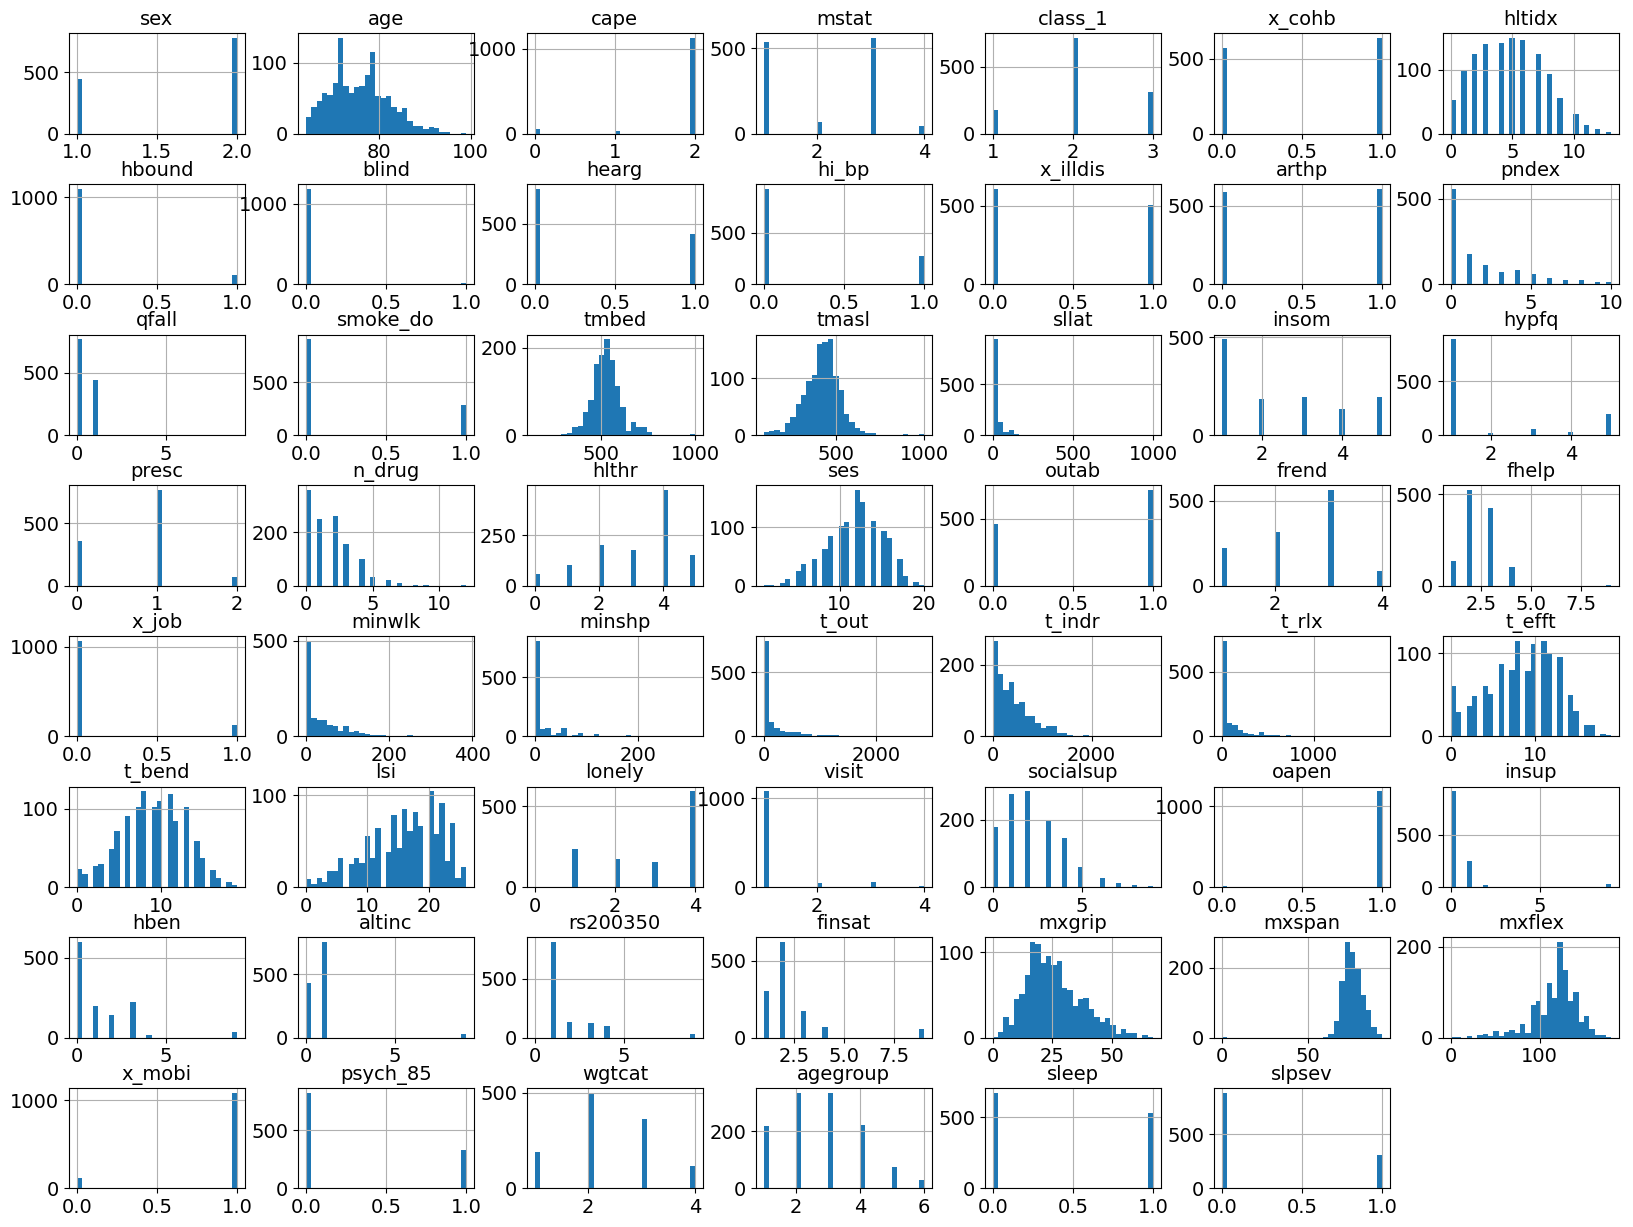

In [59]:
# Histograms
axes = df.hist(bins=30, figsize=(20, 15),
              xlabelsize=14,
              ylabelsize=14)

for ax in axes.ravel():
    ax.set_title(ax.get_title(), fontsize=14)
    ax.tick_params(axis='both', labelsize=14)

# Increase distance between subplots (default is around 0.2)
plt.subplots_adjust(hspace=0.5, wspace=0.3)

plt.show()

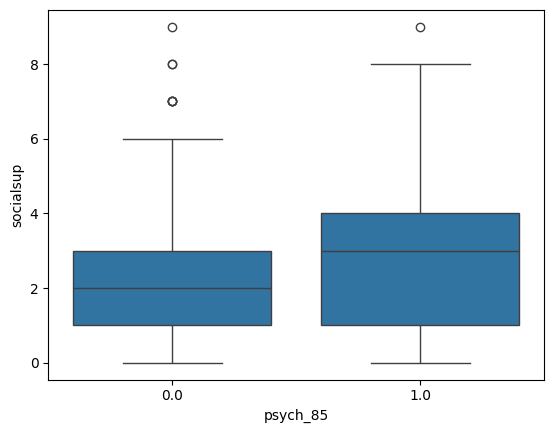

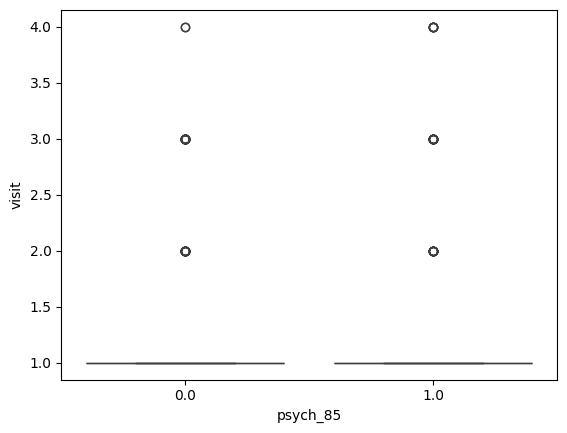

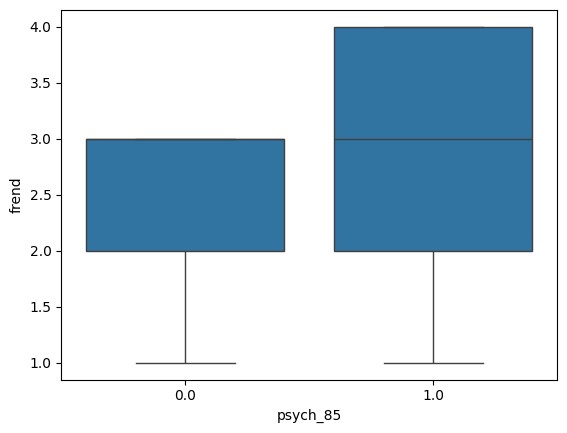

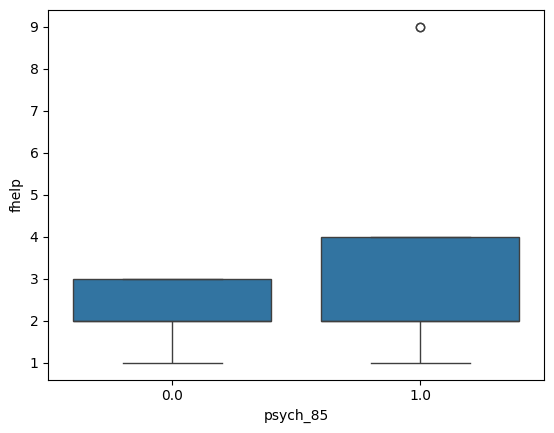

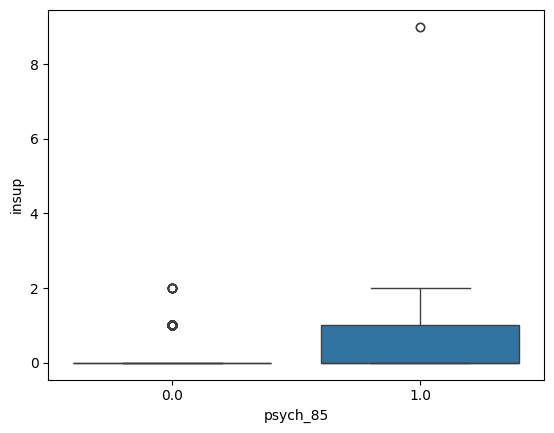

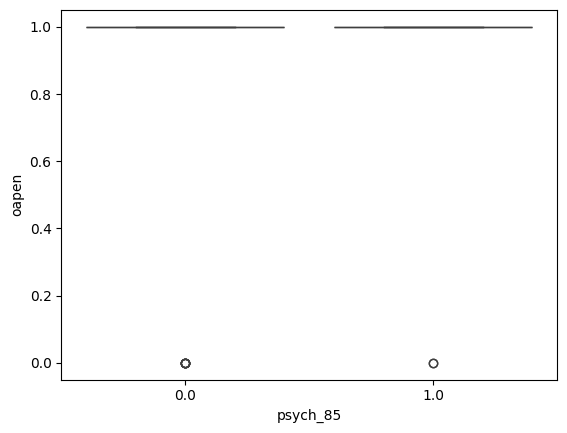

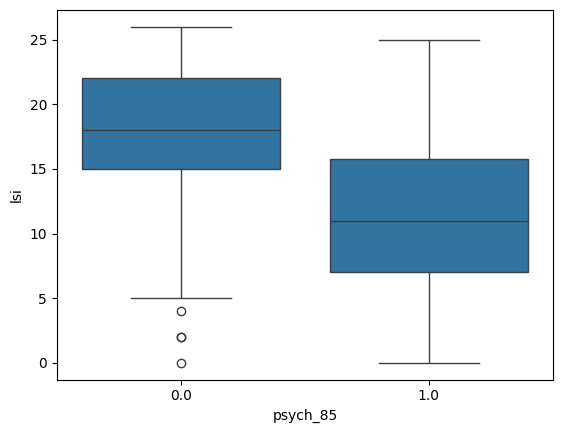

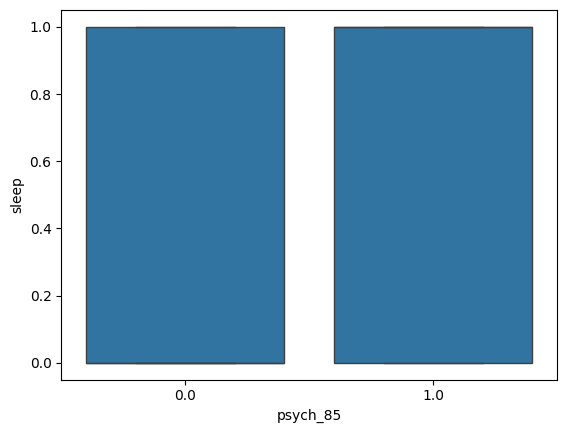

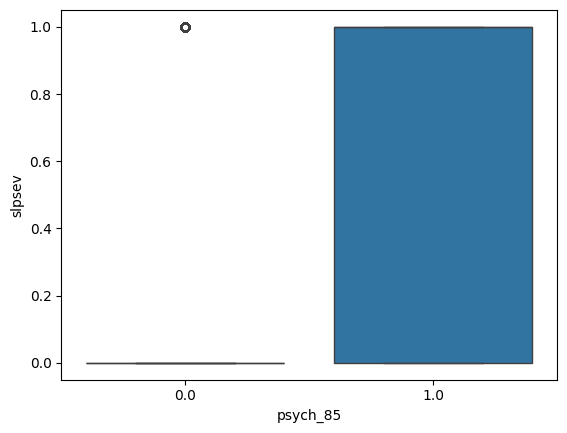

In [ ]:
possible_mediators = [
    "socialsup",
    "visit",
    "frend",
    "fhelp",
    "insup",
    "oapen",
    "lsi",
    "sleep",
    "slpsev"
]

for x in possible_mediators:
    boxplot = sns.boxplot(x="psych_85", y=x, data=df)
    plt.show()

In [12]:
# Outcome rate by loneliness level

outcome_by_loneliness = (
    data
    .groupby(TREATMENT)[OUTCOME]
    .agg(["mean", "count"])
)

outcome_by_loneliness["percentage"] = (
    outcome_by_loneliness["mean"] * 100
)

display(outcome_by_loneliness)

,mean,count,percentage
lonely,,,
1.0,0.614407,236,61.440678
2.0,0.184971,173,18.497110
3.0,0.124183,153,12.418301
4.0,0.227504,589,22.750424


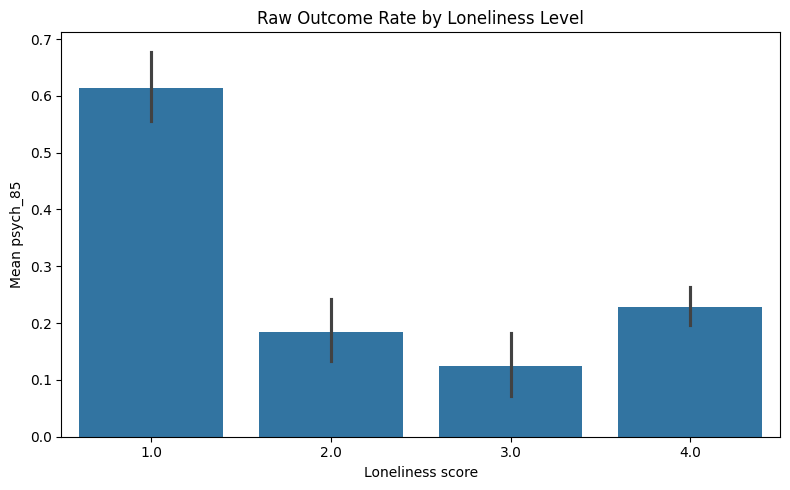

In [13]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=data,
    x=TREATMENT,
    y=OUTCOME
)

plt.xlabel("Loneliness score")
plt.ylabel("Mean psych_85")
plt.title("Raw Outcome Rate by Loneliness Level")
plt.tight_layout()
plt.show()

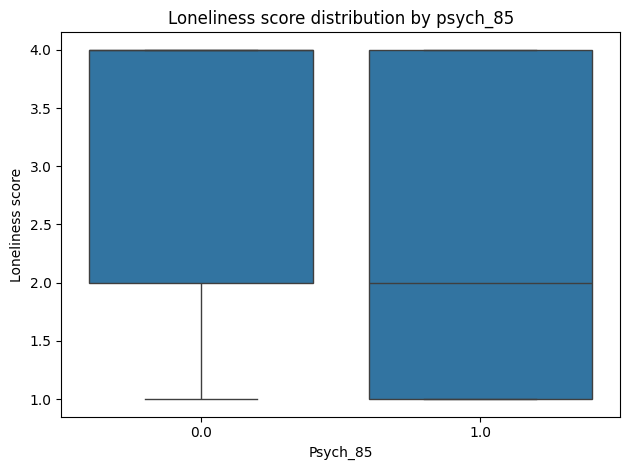

In [64]:
boxplot = sns.boxplot(x=OUTCOME, y=TREATMENT, data=data)
plt.ylabel("Loneliness score")
plt.xlabel("Psych_85")
plt.title("Loneliness score distribution by psych_85")
plt.tight_layout()
plt.show()

## 5. OLS benchmark

OLS treats the loneliness score as a linear numeric variable.

This is useful as a benchmark, but it imposes the assumption that the effect of increasing loneliness by one point is constant across all levels.

In [14]:
X_ols = pd.DataFrame(
    X,
    columns=confounders,
    index=data.index
)

# Numeric loneliness score
X_ols = pd.concat(
    [data[[TREATMENT]], X_ols],
    axis=1
)

X_ols = sm.add_constant(X_ols)

ols = sm.OLS(
    Y,
    X_ols
).fit(
    cov_type="HC3"
)

print(ols.summary())

print("\nOLS coefficient for loneliness:")
print(ols.params[TREATMENT])

print("\n95% CI:")
print(tuple(ols.conf_int().loc[TREATMENT]))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.279
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     22.14
Date:                Sat, 22 Aug 2026   Prob (F-statistic):           2.07e-75
Time:                        12:31:30   Log-Likelihood:                -531.40
No. Observations:                1151   AIC:                             1111.
Df Residuals:                    1127   BIC:                             1232.
Df Model:                          23                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2804      0.233      1.205      0.2

## 6. Random Forest DML

Here the treatment is **discrete and multi-valued (1, 2, 3, 4)**.

We do not incorrectly convert it into a binary treatment.

The DML estimator learns nonlinear nuisance functions using Random Forests.

In [15]:
rf_y = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_t = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

dml_rf = LinearDML(
    model_y=rf_y,
    model_t=rf_t,
    discrete_treatment=True,
    discrete_outcome=True,
    cv=5,
    random_state=RANDOM_STATE
)

dml_rf.fit(
    Y,
    T,
    X=X
)

print("Random Forest DML fitted successfully.")

Random Forest DML fitted successfully.


In [16]:
# Estimate treatment effects relative to the reference treatment = 1

for treatment_level in [2, 3, 4]:
    effect = dml_rf.effect(
        X,
        T0=1,
        T1=treatment_level
    )

    ate = float(np.asarray(effect).mean())

    lb, ub = dml_rf.effect_interval(
        X,
        T0=1,
        T1=treatment_level,
        alpha=0.05
    )

    lb = float(np.asarray(lb).mean())
    ub = float(np.asarray(ub).mean())

    print(
        f"Loneliness {treatment_level} vs 1: "
        f"ATE = {ate:.4f}, "
        f"95% CI = ({lb:.4f}, {ub:.4f})"
    )

Loneliness 2 vs 1: ATE = -0.4169, 95% CI = (-0.8130, -0.0209)
Loneliness 3 vs 1: ATE = -0.4909, 95% CI = (-0.8697, -0.1122)
Loneliness 4 vs 1: ATE = -0.3523, 95% CI = (-0.6880, -0.0167)


## 7. XGBoost DML

In [17]:
xgb_y = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_t = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=4,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

dml_xgb = LinearDML(
    model_y=xgb_y,
    model_t=xgb_t,
    discrete_treatment=True,
    discrete_outcome=True,
    cv=5,
    random_state=RANDOM_STATE
)

dml_xgb.fit(
    Y,
    T,
    X=X
)

print("XGBoost DML fitted successfully.")

XGBoost DML fitted successfully.


In [18]:
xgb_results = []

for treatment_level in [2, 3, 4]:
    effect = dml_xgb.effect(
        X,
        T0=1,
        T1=treatment_level
    )

    ate = float(np.asarray(effect).mean())

    lb, ub = dml_xgb.effect_interval(
        X,
        T0=1,
        T1=treatment_level,
        alpha=0.05
    )

    xgb_results.append({
        "Comparison": f"{treatment_level} vs 1",
        "ATE": ate,
        "CI Lower": float(np.asarray(lb).mean()),
        "CI Upper": float(np.asarray(ub).mean())
    })

xgb_results = pd.DataFrame(xgb_results)
display(xgb_results)

,Comparison,ATE,CI Lower,CI Upper
0,2 vs 1,-0.378268,-0.791552,0.035017
1,3 vs 1,-0.485662,-0.872154,-0.099169
2,4 vs 1,-0.345495,-0.690819,-0.000170


## 8. Lasso DML

Lasso is a useful linear/regularized benchmark against the nonlinear Random Forest and XGBoost models.

In [67]:
from sklearn.linear_model import LogisticRegressionCV

lasso_y = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegressionCV(
        Cs=10,
        cv=5,
        penalty="l1",
        solver="saga",
        max_iter=10000,
        random_state=RANDOM_STATE
    ))
])

lasso_t = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegressionCV(
        Cs=10,
        cv=5,
        penalty="l1",
        multi_class="multinomial",
        solver="saga",
        max_iter=10000,
        random_state=RANDOM_STATE
    ))
])

dml_lasso = LinearDML(
    model_y=lasso_y,
    model_t=lasso_t,
    discrete_treatment=True,
    discrete_outcome=True,
    cv=5,
    random_state=RANDOM_STATE
)

dml_lasso.fit(
    Y,
    T,
    X=X
)

print("Lasso DML fitted successfully.")

Lasso DML fitted successfully.


In [28]:
lasso_results = []

for treatment_level in [2, 3, 4]:
    effect = dml_lasso.effect(
        X,
        T0=1,
        T1=treatment_level
    )

    ate = float(np.asarray(effect).mean())

    lb, ub = dml_lasso.effect_interval(
        X,
        T0=1,
        T1=treatment_level,
        alpha=0.05
    )

    lasso_results.append({
        "Comparison": f"{treatment_level} vs 1",
        "ATE": ate,
        "CI Lower": float(np.asarray(lb).mean()),
        "CI Upper": float(np.asarray(ub).mean())
    })

lasso_results = pd.DataFrame(lasso_results)
display(lasso_results)

,Comparison,ATE,CI Lower,CI Upper
0,2 vs 1,-0.411136,-0.818157,-0.004115
1,3 vs 1,-0.488229,-0.873438,-0.103021
2,4 vs 1,-0.345586,-0.684940,-0.006231


## 9. Compare DML estimates

Each estimate answers:

> What is the estimated difference in `psych_85` if an individual were at loneliness level 2, 3, or 4 rather than level 1, conditional on the observed confounders?

This is more appropriate for the 1–4 treatment than reporting one single coefficient that assumes linearity across loneliness levels.

In [29]:
comparison = pd.DataFrame({
    "Comparison": ["2 vs 1", "3 vs 1", "4 vs 1"],
    "RF ATE": [
        float(np.asarray(dml_rf.effect(X, T0=1, T1=2)).mean()),
        float(np.asarray(dml_rf.effect(X, T0=1, T1=3)).mean()),
        float(np.asarray(dml_rf.effect(X, T0=1, T1=4)).mean())
    ],
    "XGB ATE": xgb_results["ATE"].values,
    "Lasso ATE": lasso_results["ATE"].values
})

display(comparison)

,Comparison,RF ATE,XGB ATE,Lasso ATE
0,2 vs 1,-0.416942,-0.378268,-0.411136
1,3 vs 1,-0.490936,-0.485662,-0.488229
2,4 vs 1,-0.352334,-0.345495,-0.345586


## 10. Causal Forest

Causal Forest is used to explore whether the treatment effect differs between individuals.

Because the treatment has four levels, we explicitly estimate each comparison against the reference level 1.

In [30]:
cf_y = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cf_t = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cf = CausalForestDML(
    model_y=cf_y,
    model_t=cf_t,
    n_estimators=500,
    min_samples_leaf=10,
    max_depth=8,
    discrete_treatment=True,
    discrete_outcome=True,
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cf.fit(
    Y,
    T,
    X=X
)

print("Causal Forest fitted successfully.")

Causal Forest fitted successfully.


In [31]:
cf_results = []

for treatment_level in [2, 3, 4]:
    effects = cf.effect(
        X,
        T0=1,
        T1=treatment_level
    )

    ate = float(np.asarray(effects).mean())

    lb, ub = cf.effect_interval(
        X,
        T0=1,
        T1=treatment_level,
        alpha=0.05
    )

    cf_results.append({
        "Comparison": f"{treatment_level} vs 1",
        "ATE": ate,
        "CI Lower": float(np.asarray(lb).mean()),
        "CI Upper": float(np.asarray(ub).mean())
    })

cf_results = pd.DataFrame(cf_results)
display(cf_results)

,Comparison,ATE,CI Lower,CI Upper
0,2 vs 1,-0.335877,-0.504248,-0.167505
1,3 vs 1,-0.371857,-0.554067,-0.189647
2,4 vs 1,-0.261126,-0.430014,-0.092237


## 11. Positivity / treatment overlap

For a multi-valued treatment, every relevant treatment level should have adequate probability for individuals with comparable confounder profiles.

We inspect the treatment distribution and use a multinomial Random Forest to estimate generalized propensity scores.

In [32]:
propensity_model = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

propensity_model.fit(X, T)

propensity = propensity_model.predict_proba(X)
propensity_classes = propensity_model.classes_

print("Treatment classes:", propensity_classes)

gps = pd.DataFrame(
    propensity,
    columns=[f"P(T={c}|X)" for c in propensity_classes]
)

display(gps.describe())

Treatment classes: [1 2 3 4]


,P(T=1|X),P(T=2|X),P(T=3|X),P(T=4|X)
count,1151.000000,1151.000000,1151.000000,1151.000000
mean,0.204125,0.150931,0.132885,0.512059
std,0.132332,0.067536,0.039770,0.161830
min,0.008843,0.025715,0.053727,0.215481
25%,0.088587,0.097091,0.105210,0.376684
50%,0.183974,0.142979,0.127300,0.465577
75%,0.297158,0.198680,0.154818,0.651670
max,0.607604,0.338912,0.289192,0.885126


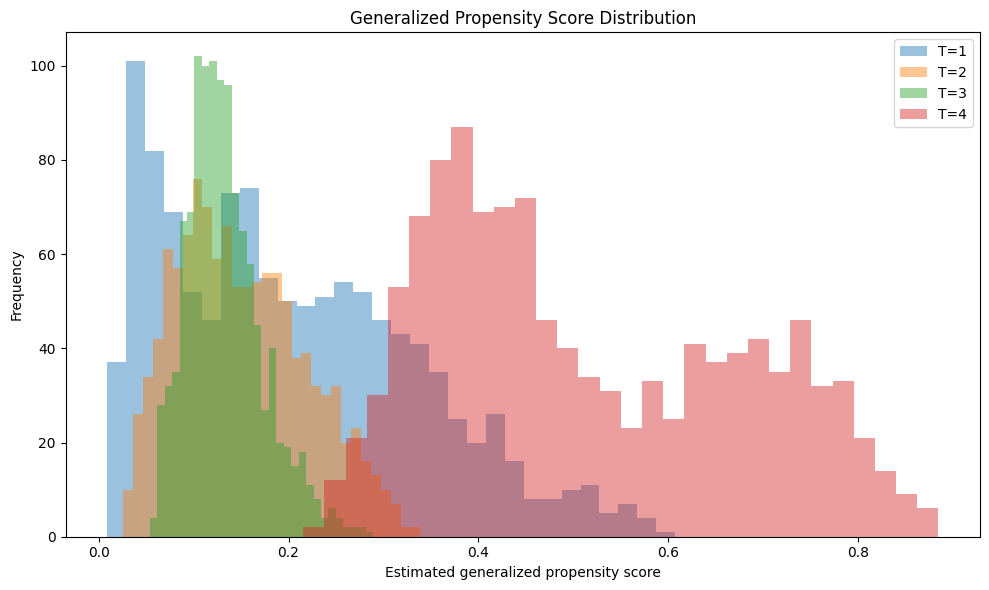

In [33]:
# Visualize generalized propensity scores

plt.figure(figsize=(10,6))

for i, treatment_level in enumerate(propensity_classes):
    plt.hist(
        propensity[:, i],
        bins=30,
        alpha=0.45,
        label=f"T={treatment_level}"
    )

plt.xlabel("Estimated generalized propensity score")
plt.ylabel("Frequency")
plt.title("Generalized Propensity Score Distribution")
plt.legend()
plt.tight_layout()
plt.show()

Propensity Score Distribution with different loneliness level shows comparable confounder profiles of different treatment groups.

# Final interpretation

### Primary strategy

Report the DML estimates for:

- loneliness **2 vs 1**
- loneliness **3 vs 1**
- loneliness **4 vs 1**

for OLS, Random Forest DML, XGBoost DML, Lasso DML with 95% confidence intervals and sensitivy checking with causal forest.


### Results
Extreme loneliness significantly increases the likelihood of depression and anxiety by 35% to 50%. However, as extreme loneliness is used as the baseline, we do not examine changes across the other levels of loneliness (e.g., 2 vs. 3 or 3 vs. 4) using Random Forest DML, XGB DML, or Lasso DML. The OLS results show that a one-level increase in loneliness significantly increases the likelihood of depression and anxiety by approximately 4.68%.  


### Important limitation
Because there is only one observation at loneliness level 0, we exclude it to avoid estimating a treatment category based on a single observation. In addition, the dataset is relatively small, with 1151 observations included in the analysis, which may limit the generalizability of the results.

